In [1]:
%cd ../
import os
import math
import cv2
import numpy as np
import paddle
import paddle.nn as nn
# import matplotlib.pyplot as plt
import paddle.nn.functional as F
paddle.set_device('cpu')
from PIL import Image, ImageEnhance
import time
import matplotlib.pyplot as plt
import paddleseg

e:\code\git\PaddleSeg


## 我的模块

In [2]:
from paddleseg.models.losses import MyL1Loss_1, MyCrossEntropyLoss, MyDisTransCrossEntropyLoss

In [3]:
logit = np.ones(shape=(1,2,512,512), dtype=np.float32)*255
# 设置背景
logit[:,0,:,:] = logit[:,0,:,:]*0
logit[:,0,100:200, 200:300] = 255
# 设置前景
logit[:,1,100:200, 200:300] = 0
logit_tensor = paddle.to_tensor(logit, dtype=paddle.float32)

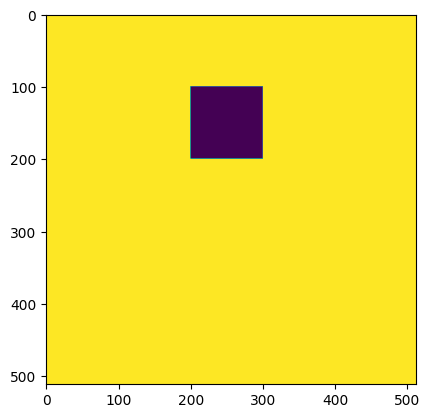

In [4]:
label_img = np.ones(shape=(512,512), dtype=np.uint8)
label_img[100:200, 200:300] = 0
label = label_img[np.newaxis,...]
label_tensor = paddle.to_tensor(label, dtype=paddle.int64)
plt.imshow(label_img)

In [5]:
losser = MyL1Loss_1(with_softmax=False)
out = losser(logit_tensor, label_tensor)
print(out.numpy())

[127.]


In [6]:
losser = MyCrossEntropyLoss()
out = losser(logit_tensor, label_tensor)
print(out.numpy())

[1.4094028]


In [13]:
losser = MyDisTransCrossEntropyLoss(min_val=0.999998)
out = losser(logit_tensor, label_tensor)
print(out.numpy())

[7.531198e-05]


# 交叉熵实验

In [ ]:
label_img = np.ones(shape=(512,512), dtype=np.uint8)
label_img[100:200, 200:300] = 0
plt.imshow(label_img)

In [ ]:
logit = np.ones(shape=(1,2,512,512), dtype=np.float32)
# 设置背景
logit[:,0,:,:] = logit[:,0,:,:]*0
logit[:,0,100:200, 200:300] = 1
# 设置前景
logit[:,1,100:200, 200:300] = 0

In [ ]:
logit_tensor = paddle.to_tensor(logit, dtype=paddle.float32)

In [ ]:
# int64形式的
label = label_img[np.newaxis,...]
label = paddle.to_tensor(label, dtype=paddle.int64)

_logit = paddle.transpose(logit_tensor, [0, 2, 3, 1])
_logit[:,30:60,30:60,0] = 0.2
_logit[:,30:60,30:60,1] = 0.8

losser = nn.CrossEntropyLoss(use_softmax=False)
avg_loss = losser(_logit, label)
print(avg_loss.numpy())

In [ ]:
label_int64 = label_img[np.newaxis,...]
label_int64 = paddle.to_tensor(label_int64, dtype=paddle.int64)
label_int64 = label_int64.numpy()
label_float32 = np.zeros(logit_tensor.shape, dtype=np.float32)
for i in range(0, len(label_int64)):
    # print("ddd")
    _mask0 = label_int64[i] == 0
    label_float32[i][0][_mask0] = 1.0
    _mask1 = label_int64[i] == 1
    label_float32[i][1][_mask1] = 1.0
label_float32 = paddle.to_tensor(label_float32)

In [ ]:
plt.imshow(label_float32[0][0])

In [ ]:
# float32 形式的， 软标签时将必须使用
label = paddle.transpose(label_float32, [0, 2, 3, 1])
# label = paddle.transpose(logit_tensor, [0, 2, 3, 1])
# label[:,30:60,30:60,0] = 0.2
# label[:,30:60,30:60,1] = 0.8

_logit = paddle.transpose(logit_tensor, [0, 2, 3, 1])
_logit[:,30:60,30:60,0] = 0.0
_logit[:,30:60,30:60,1] = 1

# losser = nn.CrossEntropyLoss(use_softmax=False, soft_label=True, reduction='mean')
losser = nn.L1Loss(reduction='mean')
avg_loss = losser(_logit, label)
print(avg_loss.numpy())

In [ ]:
probs = np.linspace(0.00001, 0.99999, 1000)
loss_list = []
for i in range(0, len(probs)):
    _logit[:,30:60,30:60,0] = 1.0-probs[i]
    _logit[:,30:60,30:60,1] = probs[i]
    _avg_loss = losser(_logit, label)
    loss_list.append(_avg_loss.numpy()[0])

In [ ]:
plt.plot(probs, loss_list)